# Self Organising Map Challenge

## The Kohonen Network

The Kohonen Self Organising Map (SOM) provides a data visualization technique which helps to understand high dimensional data by reducing the dimensions of data to a map. SOM also represents clustering concept by grouping similar data together.

Unlike other learning technique in neural networks, training a SOM requires no target vector. A SOM learns to classify the training data without any external supervision.

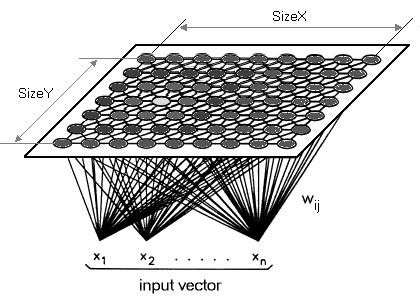


### Structure
A network has a width and a height that descibes the grid of nodes.  For example, the grid may be 4x4, and so there would be 16 nodes.

Each node has a weight for each value in the input vector.  A weight is simply a float value that the node multiplies the input value by to determine how influential it is (see below)

Each node has a set of weights that match the size of the input vector.  For example, if the input vector has 10 elements, each node would have 10 weights.

### Training
To train the network

1. Each node's weights are initialized.
2. We enumerate through the training data for some number of iterations (repeating if necessary).  The current value we are training against will be referred to as the `current input vector`
3. Every node is examined to calculate which one's weights are most like the input vector. The winning node is commonly known as the Best Matching Unit (BMU).
4. The radius of the neighbourhood of the BMU is now calculated. This is a value that starts large, typically set to the 'radius' of the lattice,  but diminishes each time-step. Any nodes found within this radius are deemed to be inside the BMU's neighbourhood.
5. Each neighbouring node's (the nodes found in step 4) weights are adjusted to make them more like the input vector. The closer a node is to the BMU, the more its weights get altered.
6. Go to step 2 until we've completed N iterations.
    

### Calculating the Best Matching Unit (BMU)

To determine the best matching unit, one method is to iterate through all the nodes and calculate the Euclidean distance between each node's weight vector and the current input vector. The node with a weight vector closest to the input vector is tagged as the BMU.

The Euclidean distance $\mathsf{distance}_{i}$ (from the input vector $V$ to the $i$th node's weights $W_i$)is given as (using Pythagoras):

$$ \mathsf{distance}_{i}=\sqrt{\sum_{k=0}^{k=n}(V_k - W_{i_k})^2}$$

where V is the current input vector and $W_i$ is the node's weight vector.  $n$ is the size of the input & weight vector.

*Note*: $V$ and $W$ are vectors.  $V$ is the input vector, and $W_i$ is the weight vector of the $i$th node.  $V_k$ and $W_{i_k}$ represent the $k$'th value within those vectors.  

The BMU is the node with the minimal distance for the current input vector

### Calculating the Neighbourhood Radius

The next step is to calculate which of the other nodes are within the BMU's neighbourhood. All these nodes will have their weight vectors altered.

First we calculate what the radius of the neighbourhood should be and then use Pythagoras to determine if each node is within the radial distance or not.

A unique feature of the Kohonen learning algorithm is that the area of the neighbourhood shrinks over time. To do this we use the exponential decay function:

Given a desired number of training iterations $n$:
$$n_{\mathsf{max iterations}} = 100$$

Calculate the radius $\sigma_t$ at iteration number $t$:

$$\sigma_t = \sigma_0 \exp\left(- \frac{t}{\lambda} \right) \qquad t = 1,2,3,4... $$

Where $\sigma_0$ denotes the neighbourhood radius at iteration $t=0$, $t$ is the current iteration. We define $\sigma_0$ (the initial radius) and $\lambda$ (the time constant) as below:

$$\sigma_0 = \frac{\max(width,height)}{2} \qquad \lambda = \frac{n_{\mathsf{max iterations}}}{\log(\sigma_0)} $$

Where $width$ & $height$ are the width and height of the grid.

### Calculating the Learning Rate

We define the initial leanring rate $\alpha_0$ at iteration $t = 0$ as:
$$\alpha_0 = 0.1$$

So, we can calculate the learning rate at a given iteration t as:

$$\alpha_t = \alpha_0 \exp \left(- \frac{t}{\lambda} \right) $$

where $t$ is the iteration number, $\lambda$ is the time constant (calculated above)
        
### Calculating the Influence

As well as the learning rate, we need to calculate the influence $\theta_t$ of the learning/training at a given iteration $t$.  

So for each node, we need to caclulate the euclidean distance $d_i$ from the BMU to that node.  Similar to when we calculate the distance to find the BMU, we use Pythagoras.  The current ($i$th) node's x position is given by $x(W_i)$, and the BMU's x position is, likewise, given by $x(Z)$.  Similarly, $y()$ returns the y position of a node.

$$ d_{i}=\sqrt{(x(W_i) - x(Z))^2 + (y(W_i) - y(Z))^2} $$

Then, the influence decays over time according to:

$$\theta_t = \exp \left( - \frac{d_{i}^2}{2\sigma_t^2} \right) $$

Where $\sigma_t$ is the neighbourhood radius at iteration $t$ as calculated above.

Note: You will need to come up with an approach to x() and y().


### Updating the Weights

To update the weights of a given node, we use:

$$W_{i_{t+1}} = W_{i_t} + \alpha_t \theta_t (V_t - W_{i_t})$$
        
So $W_{i_{t+1}}$ is the new value of the weight for the $i$th node, $V_t$ is the current value of the training data, $W_{i_t}$ is the current weight and $\alpha_t$ and $\theta_t$ are the learning rate and influence calculated above.

*Note*: the $W$ and $V$ are vectors

### Example 10x10 network after 100 iterations

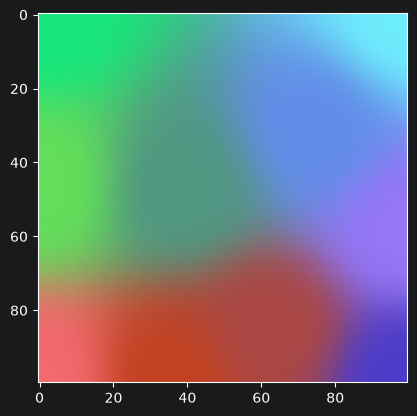

In [2]:
import matplotlib.pyplot as plt
plt.imshow(image_data)

### Example 100x100 network after 1000 iterations

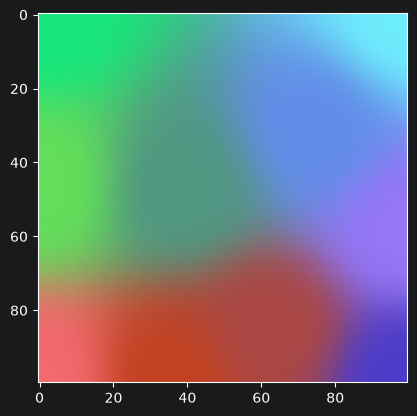

In [3]:
import matplotlib.pyplot as plt
plt.imshow(image_data)

## Challenge

Sam has written an implementation of a Self Organising Map. Consider the following criteria when assessing Sam's code:

- Could the code be made more efficient? A literal interpretation of the instructions above is not necessary.
- Is the code best structured for later use by other developers and in anticipation of productionisation?
- How would you approach productionising this application?
- Anything else you think is relevant.

In [ ]:
# kohonen.py
import matplotlib.pyplot as plt
import numpy as np

def train(input_data, n_max_iterations, width, height):
    σ0 = max(width, height) / 2
    α0 = 0.1
    weights = np.random.random((width, height, 3))
    λ = n_max_iterations / np.log(σ0)
    for t in range(n_max_iterations):
        σt = σ0 * np.exp(-t/λ)
        αt = α0 * np.exp(-t/λ)
        for vt in input_data:
            bmu = np.argmin(np.sum((weights - vt) ** 2, axis=2))
            bmu_x, bmu_y = np.unravel_index(bmu, (width, height))
            for x in range(width):
                for y in range(height):
                    di = np.sqrt(((x - bmu_x) ** 2) + ((y - bmu_y) ** 2))
                    θt = np.exp(-(di ** 2) / (2*(σt ** 2)))
                    weights[x, y] += αt * θt * (vt - weights[x, y])
    return weights

if __name__ == '__main__':
    # Generate data
    input_data = np.random.random((10,3))
    image_data = train(input_data, 100, 10, 10)

    plt.imsave('100.png', image_data)

    # Generate data
    input_data = np.random.random((10,3))
    image_data = train(input_data, 1000, 100, 100)

    plt.imsave('1000.png', image_data)


KeyboardInterrupt: 

## A fixed version of the SOM train

The code Sam wrote is *correct* and produces the right picture. The changes below are about
**evaluation, efficiency and robustness**, not fixing a wrong answer. What I changed and why:

1. **Added evaluation metrics (biggest gap).** The original has no notion of "success", so you
   can't tell if training worked or choose between hyperparameters. I added **quantisation error
   (QE)** — the mean distance from each input to its closest node (BMU), the SOM's primary metric —
   and **topographic error (TE)** for topology preservation. QE is logged per iteration so we can
   plot a learning curve and compare settings.
2. **Vectorised the per-node update.** Sam looped over every node in pure Python
   (`for x ... for y ...`) — at 100×100 / 1000 iterations that's ~100M scalar iterations. The grid
   coordinates are constant, so I build them once and compute all distances / influences / the
   update as whole-array broadcasts.
3. **Inferred the input dimensionality** from the data instead of hard-coding `3` (RGB) — pass
   10-dimensional data and it just works, matching the spec.
4. **Guarded the `λ = n / log(σ0)` edge case** — `log(σ0)` is 0 (divide-by-zero) when
   `max(width, height) <= 2`.
5. **Seeded the RNG** for reproducibility, and renamed the non-ASCII Greek identifiers
   (`σ0, α0, λ, θt …`) to PEP 8 snake_case so the code is typable and linter-friendly.

What I deliberately **left alone**: the vectorised BMU search and the `argmin` on *squared*
distance (skipping the monotonic `sqrt`) are correct, deliberate optimisations.


In [5]:
# kohonen.py -- a fixed, vectorised version of Sam's train()
import matplotlib.pyplot as plt
import numpy as np


def quantisation_error(weights, data):
    """Mean distance from each input to its closest node (BMU). Lower = better.

    The SOM's primary metric: training literally pulls each BMU toward its
    inputs, so QE measures how well the map represents the data.
    """
    flat = weights.reshape(-1, weights.shape[-1])                 # (W*H, dim)
    dist = np.linalg.norm(data[:, None, :] - flat[None], axis=2)  # (N, W*H)
    return float(dist.min(axis=1).mean())


def topographic_error(weights, data):
    """Fraction of inputs whose 1st and 2nd BMUs are not grid-neighbours.

    Secondary metric: measures topology preservation (similar inputs should
    map to nearby nodes). Lower = better.
    """
    width, height, _ = weights.shape
    flat = weights.reshape(-1, weights.shape[-1])
    dist = np.linalg.norm(data[:, None, :] - flat[None], axis=2)  # (N, W*H)
    nearest_two = np.argsort(dist, axis=1)[:, :2]                 # (N, 2) flat indices
    xs, ys = np.unravel_index(nearest_two, (width, height))       # each (N, 2)
    non_adjacent = (np.abs(xs[:, 0] - xs[:, 1]) > 1) | (np.abs(ys[:, 0] - ys[:, 1]) > 1)
    return float(np.mean(non_adjacent))


def train(input_data, n_max_iterations, width, height,
          initial_learning_rate=0.1, seed=None, record_history=False):
    """Train a Kohonen SOM and return the trained weights.

    If ``record_history`` is set, also return the quantisation error after each
    iteration so the learning curve can be plotted.
    """
    input_data = np.asarray(input_data, dtype=float)
    n_features = input_data.shape[1]          # infer dim, don't hard-code 3

    rng = np.random.default_rng(seed)         # seeded => reproducible
    weights = rng.random((width, height, n_features))

    initial_radius = max(width, height) / 2.0
    # Guard: a small grid makes log(initial_radius) <= 0 (divide-by-zero / blow-up).
    log_radius = np.log(initial_radius) if initial_radius > 1 else 1.0
    time_constant = n_max_iterations / log_radius

    # Grid coordinates are constant -- build them once, outside the loops.
    xs, ys = np.meshgrid(np.arange(width), np.arange(height), indexing="ij")

    history = []
    for t in range(n_max_iterations):
        radius = initial_radius * np.exp(-t / time_constant)
        learning_rate = initial_learning_rate * np.exp(-t / time_constant)
        two_radius_sq = 2.0 * radius ** 2
        for input_vector in input_data:
            bmu = np.argmin(np.sum((weights - input_vector) ** 2, axis=-1))
            bmu_x, bmu_y = np.unravel_index(bmu, (width, height))
            # squared grid distance from EVERY node to the BMU, in one op
            grid_sq_dist = (xs - bmu_x) ** 2 + (ys - bmu_y) ** 2
            influence = np.exp(-grid_sq_dist / two_radius_sq)        # (W, H)
            weights += learning_rate * influence[..., None] * (input_vector - weights)
        if record_history:
            history.append(quantisation_error(weights, input_data))

    return (weights, history) if record_history else weights


### Evaluation metrics per experiment

Now the two runs from the brief become *measured* choices, not guesses: each prints its final
quantisation error (QE) and topographic error (TE).

In [6]:
# Reproducible experiments, now reporting metrics
data = np.random.default_rng(42).random((10, 3))

weights_100, hist_100 = train(data, 100, 10, 10, seed=42, record_history=True)
plt.imsave("100.png", weights_100)
print(f"10x10,   100 iters -> QE={quantisation_error(weights_100, data):.4f}  "
      f"TE={topographic_error(weights_100, data):.4f}")

weights_1000, hist_1000 = train(data, 1000, 100, 100, seed=42, record_history=True)
plt.imsave("1000.png", weights_1000)
print(f"100x100, 1000 iters -> QE={quantisation_error(weights_1000, data):.4f}  "
      f"TE={topographic_error(weights_1000, data):.4f}")


10x10,   100 iters -> QE=0.0770  TE=0.0000
100x100, 1000 iters -> QE=0.0001  TE=0.0000


### Learning curve — does the loss actually drop?

Plotting QE per iteration answers the hyperparameter question directly: *is the error still falling,
or flat?* If the curve has plateaued, extra iterations are wasted compute.

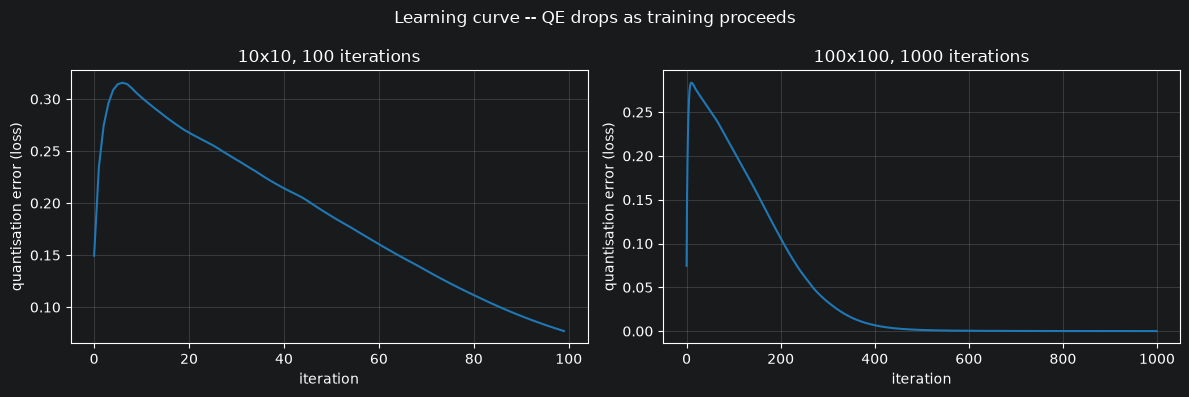

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in zip(
    axes,
    (hist_100, hist_1000),
    ("10x10, 100 iterations", "100x100, 1000 iterations"),
):
    ax.plot(hist, color="tab:blue")
    ax.set_title(title)
    ax.set_xlabel("iteration")
    ax.set_ylabel("quantisation error (loss)")
    ax.grid(True, alpha=0.3)
fig.suptitle("Learning curve -- QE drops as training proceeds")
plt.tight_layout()
plt.show()


### Hyperparameter sweep

With a metric in hand we can *select* hyperparameters instead of guessing. Below we sweep grid size,
iterations and learning rate, then rank settings by final QE (with TE alongside).

config                          QE        TE
--------------------------------------------
20x20 / 200it / lr0.5       0.0000    0.0000
10x10 / 200it / lr0.5       0.0039    0.0000
20x20 / 50it / lr0.5        0.0071    0.0000
20x20 / 200it / lr0.1       0.0145    0.0000
10x10 / 50it / lr0.5        0.0181    0.0000
10x10 / 200it / lr0.1       0.0382    0.0000
10x10 / 50it / lr0.1        0.1116    0.0000
20x20 / 50it / lr0.1        0.1310    0.0000


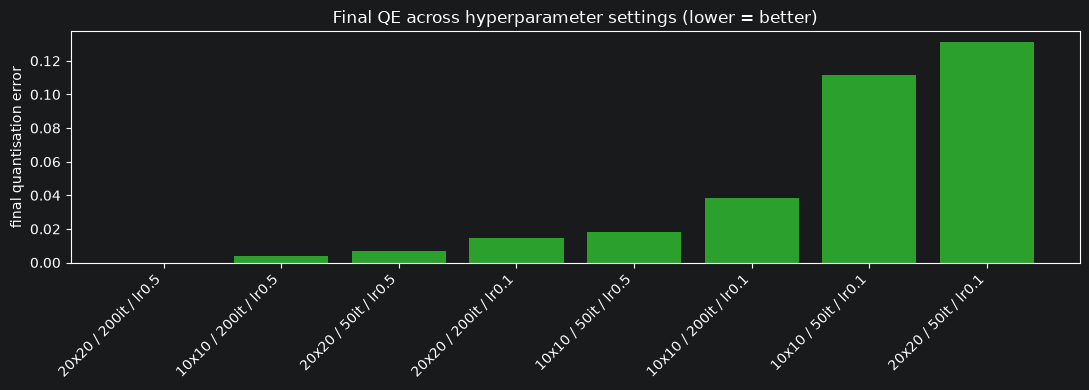

In [8]:
import itertools

grids = [(10, 10), (20, 20)]
iteration_options = [50, 200]
learning_rates = [0.1, 0.5]

results = []
for (w, h), n_iter, lr in itertools.product(grids, iteration_options, learning_rates):
    weights = train(data, n_iter, w, h, initial_learning_rate=lr, seed=42)
    results.append({
        "config": f"{w}x{h} / {n_iter}it / lr{lr}",
        "QE": quantisation_error(weights, data),
        "TE": topographic_error(weights, data),
    })

results.sort(key=lambda r: r["QE"])

print(f"{'config':<24}{'QE':>10}{'TE':>10}")
print("-" * 44)
for r in results:
    print(f"{r['config']:<24}{r['QE']:>10.4f}{r['TE']:>10.4f}")

plt.figure(figsize=(11, 4))
plt.bar([r["config"] for r in results], [r["QE"] for r in results], color="tab:green")
plt.ylabel("final quantisation error")
plt.title("Final QE across hyperparameter settings (lower = better)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
